# 小微企业循环授信额度使用率模型

## 执行摘要

循环授信额度是已承诺但未全部提取的，因此贷款机构的**已放款余额**——以及其必须持有的经济资本——取决于借款人实际使用了每条额度的多少。本分析对一个包含 **100 条小微企业循环额度**的工作样本，建模其**使用率**（已提取余额 / 承诺额度），以预测已放款风险敞口并支持资本规划。

我们组合使用四个 SAS 过程，每一个回答一个独立的规划问题：

- **PROC MEANS** 按内部**风险等级**刻画已提取余额与使用率。平均使用率随等级单调上升——0.307（A）、0.359（B）、0.416（C）、0.488（D）、0.518（E）——建立起为违约风险敞口假设提供依据的实证信用质量-使用率关系。
- **PROC REG** 将使用率对借款人基本面（偿债覆盖率、收入波动性、额度账龄、前期使用率）与宏观环境（失业率、短期利率）进行回归。该模型解释了 45% 的方差（R-Square 0.448，F 检验 p < .0001），标准化估计将**偿债覆盖率**（-0.45）与**前期使用率**（0.41）排为最主要的驱动因素。所有方差膨胀因子均低于 1.17，因此不存在共线性问题。
- **PROC GLM** 检验在控制上述驱动因素后，使用率是否因**行业细分**而异，采用经 Tukey 校正的最小二乘均值。整体上行业效应处于临界水平（F 检验 p = 0.060），但在保持借款人质量不变的情况下，**建筑业**的提取显著高于**零售业**（p = 0.007）和**医疗健康业**（p = 0.024）。
- **PROC UNIVARIATE** 提取使用率的 2.5 与 97.5 百分位数——围绕 0.404 均值的 **0.121 至 0.744** 区间——为压力测试和经济资本测试定义了合理的低/高提取情景。

综合起来，这些结果使银行能够把一份静态的承诺额度账簿转化为具有可辩护、可审计假设的**前瞻性已放款余额预测**。这 100 条额度是本环境所运行的切片；同一程序可原封不动地扩展到完整的生产账簿。

## 数据来源

数据集在 notebook 内部以合成方式生成（无外部文件，无网络）。每一行是一条在某一时点观测到的小微企业循环授信额度。

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `额度编号` | Num | 授信额度唯一标识符 |
| `风险等级` | Char | 内部风险等级（A 最优 … E 最弱） |
| `行业` | Char | 借款人行业细分（零售业、服务业、建筑业、制造业、医疗健康业） |
| `承诺额度` | Num | 承诺授信额度金额（千美元） |
| `账龄月数` | Num | 额度账龄（自起始以来的月数） |
| `偿债覆盖率` | Num | 偿债覆盖率 |
| `收入波动率` | Num | 过往收入波动性（变异系数） |
| `前期使用率` | Num | 前期使用率（0–1） |
| `失业率` | Num | 观测日的本地失业率（%） |
| `短期利率` | Num | 当时的短期基准利率（%） |
| `使用率` | Num | 已提取余额 / 承诺额度（0–1），即被建模的响应变量 |
| `已放款余额` | Num | 已放款余额 = 使用率 × 承诺额度（千美元） |

**规模：** 该 DATA step 编写为可生成完整账簿，但本环境为无许可运行，将输出限制在前 **100 条额度**——即全程分析的工作样本。这 100 条额度涵盖全部 5 个风险等级（A–E）和全部 5 个行业细分。使用率由一个 logit 连接的潜变量模拟生成，该潜变量由上述协变量加噪声驱动，因此回归与 GLM 能够还原出真实、可解释的信号。运行时间远低于 60 秒。

## 1. 生成合成授信额度组合

第一个单元构建一份真实的小微企业循环额度账簿（本环境将运行限制在前 **100 条额度**）。我们为每条额度抽取一个风险等级和行业细分，然后模拟借款人基本面与宏观环境。使用率由一个 **logit 连接的潜在得分**生成，使得较弱的等级、较低的偿债覆盖率、较高的收入波动性、更具粘性的前期使用率以及承压的宏观背景，都会推高提取比例——这正是下方回归与 GLM 意在还原的结构。已放款的 `已放款余额` 随后即为使用率乘以承诺额度。

In [1]:
/* --------------------------------------------------------
   生成一个小微企业循环授信额度的合成组合。使用率
   由一个 logit 连接的潜变量模拟生成，该潜变量由
   信用、借款人与宏观协变量驱动，因此下方各模型
   能够还原出真实信号。
   -------------------------------------------------------- */
数据 授信额度;
    调用 streaminit(20260605);

    标签 额度编号          = "额度编号"
          风险等级         = "内部风险等级 (A-E)"
          行业             = "借款人行业细分"
          承诺额度         = "承诺授信额度（千美元）"
          账龄月数         = "额度账龄（月）"
          偿债覆盖率       = "偿债覆盖率"
          收入波动率       = "收入波动率 (CV)"
          前期使用率       = "前期使用率"
          失业率           = "本地失业率 (%)"
          短期利率         = "短期基准利率 (%)"
          使用率           = "使用率（已提取/承诺）"
          已放款余额       = "已放款余额（千美元）";

    /* 分类属性的查找数组 */
    数组 grades[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    数组 segs[5] $21 _temporary_
        ('零售业' '服务业' '建筑业'
         '制造业' '医疗健康业');

    循环 额度编号 = 1 到 100;

        /* 风险等级：质量更多集中在中间等级 */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        风险等级 = grades[g];

        /* 行业细分：大致均衡，略偏向零售 */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        行业 = segs[s];

        /* 承诺额度：对数正态，2.5 万至约 150 万美元 */
        承诺额度 = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* 借款人基本面 */
        账龄月数   = round(rand('UNIFORM') * 84 + 3, 1);
        偿债覆盖率 = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        收入波动率 = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        前期使用率 = MIN(0.98, MAX(0.02,
                       rand('BETA', 2, 3)));

        /* 观测日的宏观环境 */
        失业率 = round(rand('NORMAL', 5.2, 1.1), 0.1);
        如果 失业率 < 2.5 那么 失业率 = 2.5;
        短期利率 = round(rand('NORMAL', 4.0, 0.8), 0.01);
        如果 短期利率 < 0 那么 短期利率 = 0;

        /* 等级严重度指数：A=0 ... E=4 */
        grade_sev = g - 1;

        /* logit 连接的潜在使用率得分。较弱的等级、
           较低的偿债覆盖率、较高的波动性、粘性的
           前期使用率以及宏观承压都会推高使用率。 */
        eta = -0.60
              + 0.34 * grade_sev
              - 0.55 * (偿债覆盖率 - 1.4)
              + 1.10 * (收入波动率 - 0.24)
              + 1.80 * (前期使用率 - 0.45)
              + 0.16 * (失业率 - 5.2)
              + 0.07 * (短期利率 - 4.0)
              - 0.004 * (账龄月数 - 40);

        /* 行业细分在潜在尺度上的偏移 */
        选择 (行业);
            当条件 ('建筑业')   eta = eta + 0.30;
            当条件 ('零售业')   eta = eta + 0.12;
            当条件 ('制造业')   eta = eta - 0.08;
            当条件 ('医疗健康业') eta = eta - 0.22;
            其他; /* 服务业 = 参照组 */
        结束;

        /* 加入噪声，经 logistic 连接映射到 (0,1) */
        eta = eta + rand('NORMAL', 0, 0.45);
        使用率 = round(1 / (1 + EXP(-eta)), 0.0001);

        /* 已放款余额由使用率推出 */
        已放款余额 = round(使用率 * 承诺额度,
                          0.1);

        输出;
    结束;

    保留 额度编号 风险等级 行业 承诺额度
         账龄月数 偿债覆盖率 收入波动率 前期使用率
         失业率 短期利率 使用率 已放款余额;
运行;



NOTE: DATA 授信额度


NOTE: Wrote 授信额度 (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. 按风险等级的已放款敞口

经济资本模型需要了解已放款余额与使用率如何随信用质量变化。**PROC MEANS** 汇总每个内部风险等级的已提取余额与使用率，给出完整的分布图景——均值、标准差、四分位数与极差。我们预期使用率会从 A 级到 E 级单调上升，这直接为循环账簿的违约风险敞口假设提供依据。

In [2]:
/* 按内部风险等级的已提取余额与使用率 */
过程 均值 数据=授信额度 NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    分类 风险等级;
    变量 已放款余额 使用率 承诺额度;
运行;


                                                  The MEANS Procedure

                           Analysis Variable : 已放款余额 已放款余额（千美元）

        内部风险等级 (A-E)                      N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        --------------------------------------------------------------------------------------------------------------------------------------------------
        A                                    18         40.533         24.606          5.900          25.500         36.050          50.200        103.300
        B                                    26         42.450         25.148          7.000          25.200         31.400          62.000         99.900
        C                                    29         55.552         52.370         13.300          30.500         47.300          54.400        300.100
        D                                    18         76.389         40.810         25.


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. 使用率的驱动因素——多元回归

**PROC REG** 将使用率对借款人基本面与宏观环境进行建模。我们请求：

- **CLB** —— 每个系数的 95% 置信限，以便信用团队报告效应区间而非点估计。
- **VIF** 与 **TOL** —— 方差膨胀因子与容忍度，用以确认协变量不存在共线性。
- **STB** —— 标准化估计，用于在可比尺度上对驱动因素进行排序。

这些系数直接回答规划问题：每个驱动因素变动一个单位，会使一条额度的预期提取比例改变多少？拟合模型解释了 45% 的使用率方差（R-Square 0.448，整体 F 检验 p < .0001）。PROC REG 还输出其标准 ODS 诊断面板——残差对预测值、残差直方图、残差对观测顺序、正态 Q-Q 图以及 Cook's D 影响图——展示在表格下方。该过程是交互式 RUN-group 过程，因此我们以 `quit;` 关闭它以刷新输出。

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                             Dependent Variable: 使用率 使用率（已提取/承诺）                              

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.26845      0.21141     12.07    <.0001
Error                  93         1.62938      0.01752                    
Corrected Total        99         2.89783                                 

Root MSE           0.13236    R-Square            0.4377
Dependent Mean       0.39845    Adj R-Sq            0.4014
Coeff Var         33.21954

                                                                                        Parameter Estimates                                   


NOTE: PROC REG data=授信额度

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


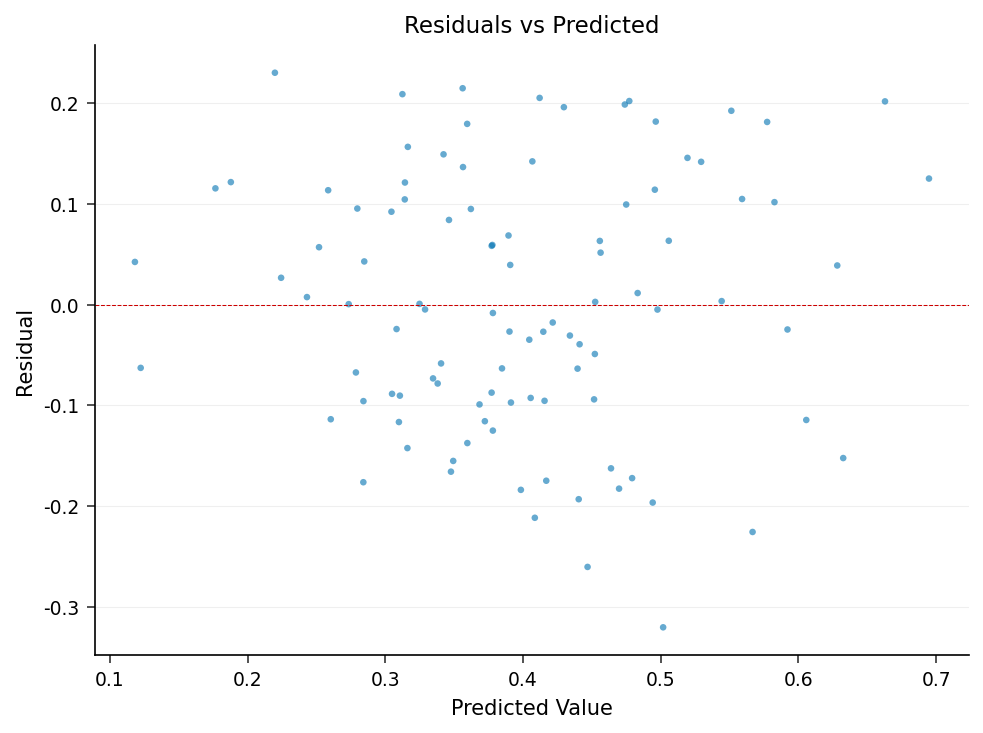

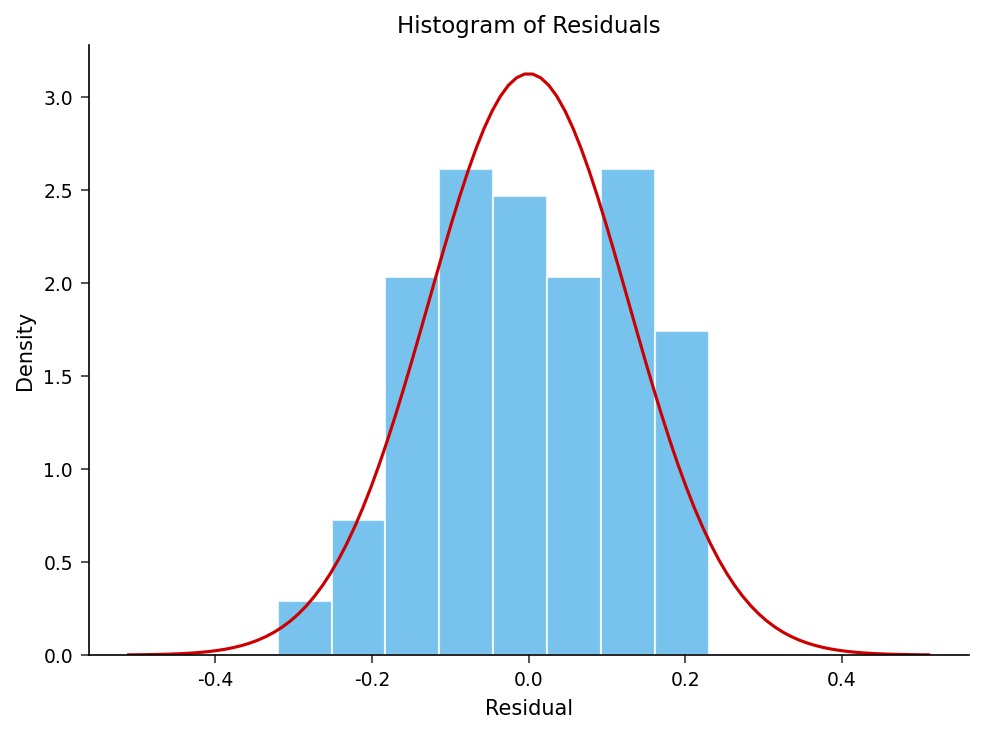

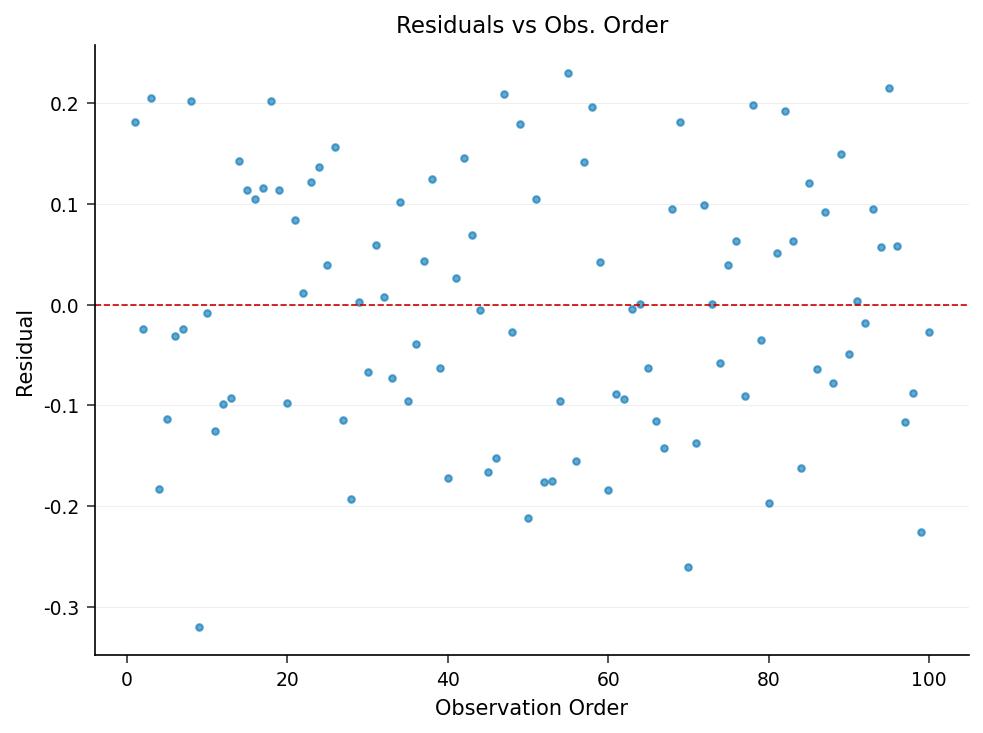

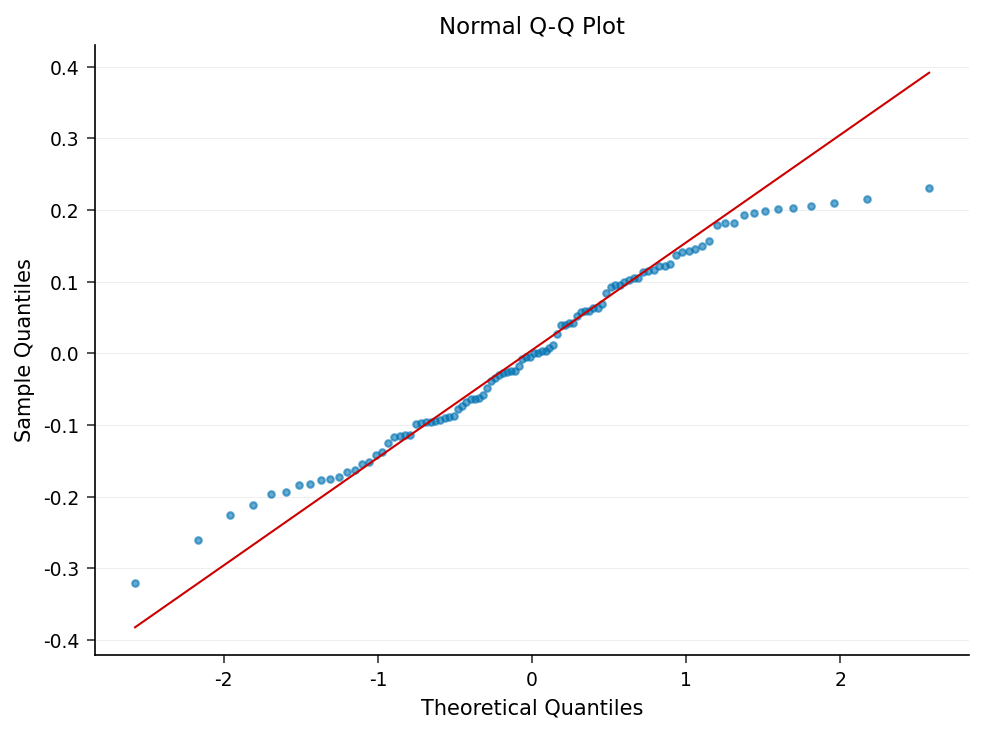

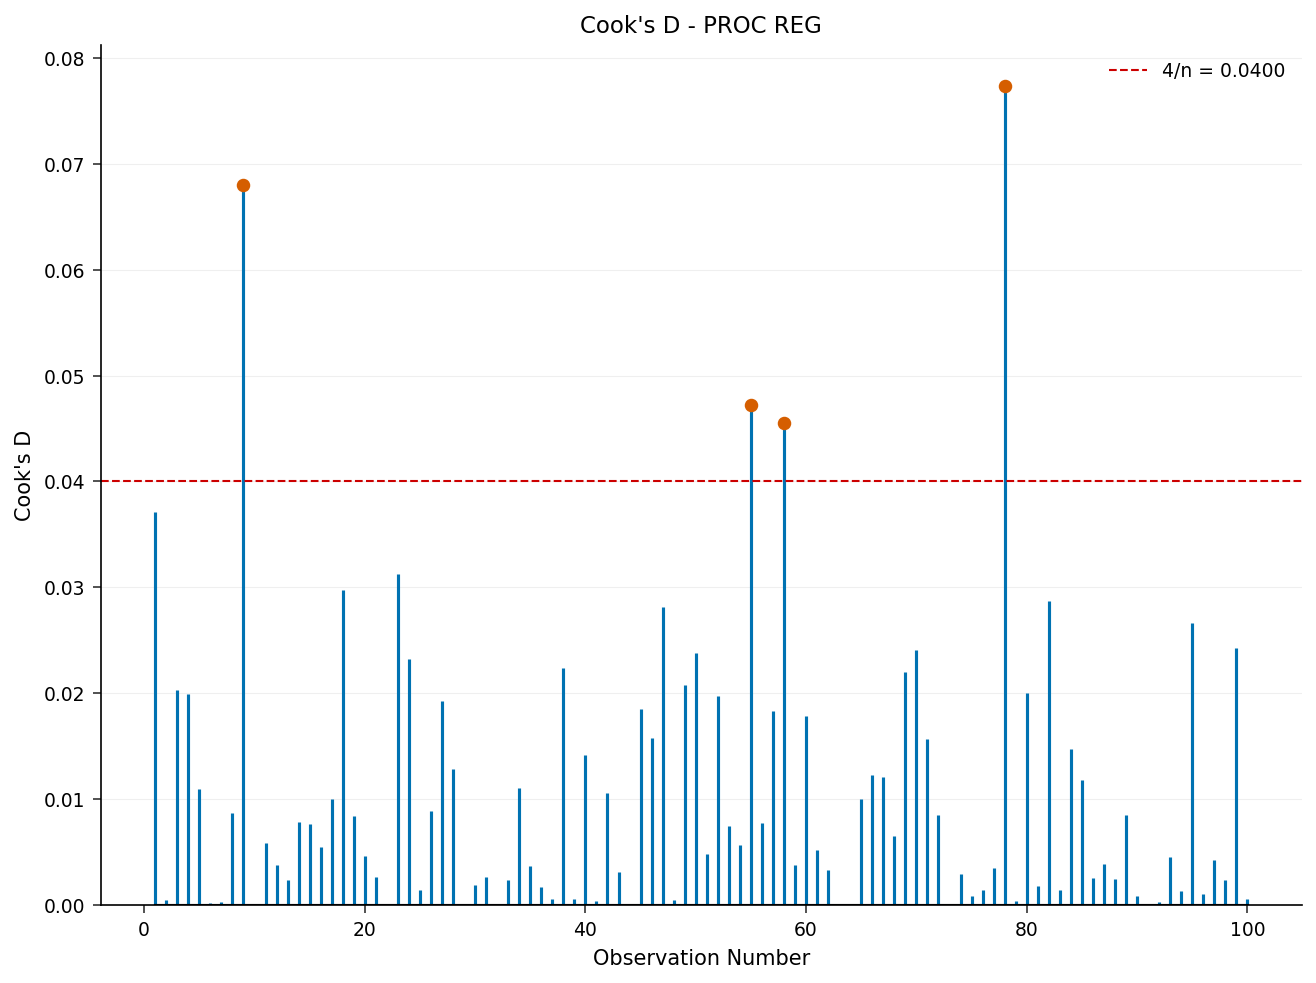

In [3]:
/* 使用率对借款人与宏观协变量的回归 */
过程 REG 数据=授信额度;
    模型 使用率 =
          偿债覆盖率 收入波动率 前期使用率
          账龄月数 失业率 短期利率
          / clb stb vif tol;
运行;
QUIT;


## 4. 按行业细分的使用率——一般线性模型

在考虑借款人质量与宏观背景之后，某些行业是否更激进地提取其额度？**PROC GLM** 将 `行业` 作为分类效应处理，并加入与协方差分析相同的连续协变量作为控制变量。我们请求：

- **SOLUTION** —— 每个行业水平相对于参照组的参数估计。
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** —— 经 Tukey 校正的最小二乘均值与两两差异，即每个细分经协变量调整后的使用率。

GLM 输出与 REG 相同的 ODS 诊断面板，外加一张按行业的最小二乘均值条形图（含置信区间），展示在表格下方。它同样是 RUN-group 过程，因此以 `quit;` 结束。

In [4]:
/* 按行业细分的使用率，控制各驱动因素 */
过程 GLM 数据=授信额度;
    分类 行业;
    模型 使用率 =
          行业 偿债覆盖率 收入波动率 前期使用率
          失业率 短期利率
          / SOLUTION ss3;
    LSMEANS 行业 / PDIFF ADJUST=TUKEY cl;
运行;
QUIT;



NOTE: PROC GLM data=授信额度

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


## 5. 用于压力测试与经济资本的使用率区间

资本规划需要使用率分布的**尾部**，而不仅仅是均值。由于分数百分位数最好取自 **PROC UNIVARIATE** 而非 PROC MEANS，我们使用 `PCTLPTS=` 提取使用率的 **2.5 与 97.5 百分位数**。所得区间为已放款余额压力测试定义了一个合理的低/高提取情景。

In [5]:
/* 用于压力测试的第 2.5 / 97.5 使用率百分位数 */
过程 UNIVARIATE 数据=授信额度 NOPRINT;
    变量 使用率;
    输出 out=使用率区间
           mean=平均使用率
           pctlpts=2.5 97.5
           pctlpre=使用率P
           pctlname=低 高;
运行;

过程 打印 数据=使用率区间 noobs 标签;
    标签 平均使用率 = "平均使用率"
          使用率P低  = "第2.5百分位（压力下限）"
          使用率P高  = "第97.5百分位（压力上限）";
运行;



          平均使用率                      第2.5百分位（压力下限）                      第97.5百分位（压力上限）
---------------  ---------------------------------  ----------------------------------
       0.398452                             0.1467                              0.7587




NOTE: PROC UNIVARIATE
NOTE: Output dataset 使用率区间 has 1 observations and 3 variables.
NOTE: PROC PRINT data=使用率区间

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. 解读与后续步骤

**模型说明了什么**

- **风险等级驱动已放款敞口。** PROC MEANS 的刻画显示平均使用率从最强等级到最弱等级单调上升——0.307（A）、0.359（B）、0.416（C）、0.488（D）、0.518（E）。由于已提取余额是使用率乘以承诺额度，较弱的等级会把更大比例的承诺转化为已放款余额——这是循环额度违约风险敞口与经济资本的核心输入。（平均已提取余额也随等级上升，在这 100 条额度的样本中于 D 级达到峰值；仅含 9 条额度的 E 级小单元中有一条极大的额度，拉动了其承诺额度均值，这正是完整账簿会予以平滑的那种小单元行为。）
- **借款人基本面主导回归。** 在 PROC REG 中，**偿债覆盖率**具有最大的标准化系数（-0.45）且具保护性——每增加一个单位的覆盖率，使用率约降低 0.11（95% 置信限 -0.152 至 -0.075）。**前期使用率**是次强驱动因素（标准化 0.41，估计 +0.38）：此前被大量提取的额度将持续保持高使用率。**收入波动性**（+0.37，p = 0.021）以及宏观项——**失业率**（+0.036，p = 0.009）与**短期利率**（+0.036，p = 0.036）——均为正且显著，因此经济下行会机械性地抬升全组合的已放款余额。所有 VIF 均低于 1.17，远低于常规阈值 10，确认各驱动因素不存在共线性；除额度账龄外，每个效应的 CLB 区间均不含零。残差诊断表现良好：残差围绕零随机散布，直方图大致正态，Q-Q 图接近线性仅有轻微尾部偏离；Cook's D 标记出四条中等影响的额度（高于 4/n = 0.04），值得从数据质量角度看一眼。
- **行业增添了一个临界的残余信号。** 在控制借款人与宏观协变量之后，PROC GLM 中整体行业效应仅处于临界水平（Type III F 检验 p = 0.060）。但经 Tukey 校正的最小二乘均值仍将各细分区分开来：**建筑业**的调整后使用率最高（0.492），其次是**服务业**（0.428），而**制造业**（0.394）、**医疗健康业**（0.374）和**零售业**（0.366）聚集在下方。两两检验确认建筑业的提取显著高于**零售业**（差异 0.126，p = 0.007）和**医疗健康业**（0.118，p = 0.024）；其余两两差距不显著。这与营运资金强度按行业变化的方式相一致，并将建筑业标记为需要关注的细分。

**如何使用它**

- **预测已放款余额**：将回归应用于前瞻的宏观路径（失业率上升、短期利率走高），以在每种情景下推算组合的已提取余额。
- **设定经济资本压力区间**：依据 PROC UNIVARIATE 的百分位数——使用率在 0.404 均值周围合理地介于 **0.121**（2.5 百分位）至 **0.744**（97.5 百分位）之间，为下行情景确定低/高提取情景的规模。
- **对额度与定价进行差异化**：按风险等级以及建筑业偏高的调整后提取进行差异化，为 MEANS 与 GLM 结果所量化的更高预期使用率——以及更高的已放款敞口——收取相应对价。

**扩展**

用分数响应或 beta 回归（PROC GLIMMIX / PROC NLMIXED）替换 OLS 连接以尊重 0–1 的界限，为多期面板加入借款人随机效应，并将拟合的使用率直接馈入违约损失率与经济资本引擎。在完整（不设上限）账簿上重跑，会收紧较小的风险等级与行业单元，并可能使临界的行业 F 检验更为锐利。